In [2]:
import pandas as pd

In [26]:
df =  pd.read_csv(r"D:\AI\spam_ham_model\combined_data.csv",encoding= 'iso-8859-1')

In [28]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [30]:
df

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...
...,...,...
83443,0,hi given a date how do i get the last date of ...
83444,1,now you can order software on cd or download i...
83445,1,dear valued member canadianpharmacy provides a...
83446,0,subscribe change profile contact us long term ...


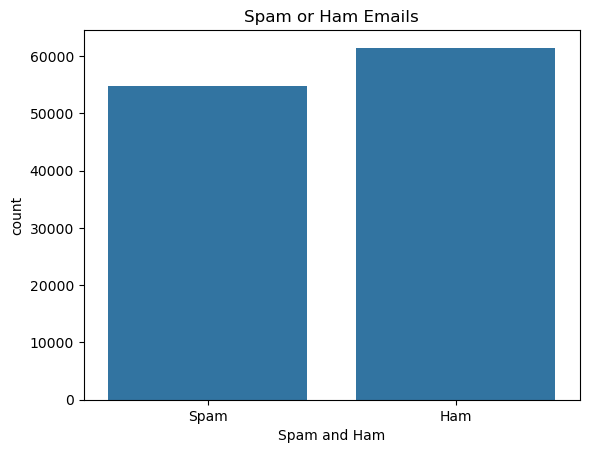

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df_reduced, x='label',)
plt.title("Spam or Ham Emails")
plt.xlabel("Spam and Ham")
plt.ylabel("count")
plt.show()

In [46]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources 
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [16]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [48]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    cleaned = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned)

In [50]:
df['clean_text'] = df['text'].apply(preprocess)

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
y= df['label']
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=32)

In [56]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [58]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      7987
           1       0.98      0.97      0.98      8703

    accuracy                           0.97     16690
   macro avg       0.97      0.97      0.97     16690
weighted avg       0.97      0.97      0.97     16690



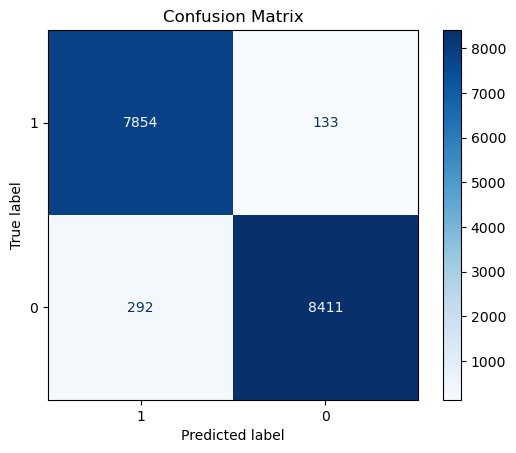

In [60]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=df['label'].unique())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [66]:
sample_text= "The GeoSolutions technology will leverage Bene"
sample_text_cleaned = preprocess(sample_text)
sample_vector = vectorizer.transform( [sample_text_cleaned])
predicted_category = model.predict(sample_vector)
label_map = {0: 'ham', 1: 'spam'}
print("Predicted Category:", label_map[predicted_category[0]])

Predicted Category: spam


In [70]:
import pickle

with open("model.pkl", 'wb') as file:
    pickle.dump(model, file)

with open("vectorizer.pkl", 'wb') as file:
    pickle.dump(vectorizer, file)